# Statistical inference of stock returns with linear regression

## Import

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
from os.path import join

import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant, graphics 
from statsmodels.graphics.tsaplots import plot_acf 
from scipy.stats import norm

In [42]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

## Load data

In [43]:
with pd.HDFStore(join('..', '..','data','assets.h5')) as store:
    data = (store['model_data']
            .dropna()
            .drop(['Open', 'Close', 'Low', 'High'], axis = 1))

## Investment universe

In [44]:
data.head()

Volume       peso_vol   peso_vol_1m  peso_vol_rank  \
Ticker     Date                                                               
AGUAS-A.SN 2010-06-28   233.100   20927.856432  16586.656795           49.0   
           2010-06-29    38.346    3442.726653  16691.559006           49.0   
           2010-06-30  3279.598  294444.256102  30591.834722           45.0   
           2010-07-01    91.056    8138.726749  30317.789583           45.0   
           2010-07-02   483.477   43406.852183  32109.656430           45.0   

                             rsi   bb_high    bb_low       atr      macd  \
Ticker     Date                                                            
AGUAS-A.SN 2010-06-28  49.667080  0.012335  0.009896 -1.764623 -0.230361   
           2010-06-29  49.667080  0.011382  0.009798 -1.770568 -0.222552   
           2010-06-30  49.667080  0.010322  0.009594 -1.776088 -0.215878   
           2010-07-01  45.266578  0.013464  0.005290 -1.773893 -0.221824   
           2010-07-02  50.034093  0.007730  0.009157 -1.771855 -0.214283   

                       return_1d  ...  weekday_4  consumer_staples  \
Ticker     Date                   ...                                
AGUAS-A.SN 2010-06-28   0.000000  ...          0                 0   
           2010-06-29   0.000000  ...          0                 0   
           2010-06-30   0.000000  ...          0                 0   
           2010-07-01  -0.004445  ...          0                 0   
           2010-07-02   0.004464  ...          1                 0   

                       financials  healthcare  industrials  \
Ticker     Date                                              
AGUAS-A.SN 2010-06-28           0           0            0   
           2010-06-29           0           0            0   
           2010-06-30           0           0            0   
           2010-07-01           0           0            0   
           2010-07-02           0           0            0   

                       materials_&_mining  other  real_estate  \
Ticker     Date                                                 
AGUAS-A.SN 2010-06-28                   0      0            0   
           2010-06-29                   0      0            0   
           2010-06-30                   0      0            0   
           2010-07-01                   0      0            0   
           2010-07-02                   0      0            0   

                       telecom_&_technology  utilities_&_energy  
Ticker     Date                                                  
AGUAS-A.SN 2010-06-28                     0                   1  
           2010-06-29                     0                   1  
           2010-06-30                     0                   1  
           2010-07-01                     0                   1  
           2010-07-02                     0                   1  

[5 rows x 79 columns]

In [45]:
data = data[data.peso_vol_rank < 100]

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 391307 entries, ('AGUAS-A.SN', Timestamp('2010-06-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-11-28 00:00:00'))
Data columns (total 79 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Volume                391307 non-null  float64
 1   peso_vol              391307 non-null  float64
 2   peso_vol_1m           391307 non-null  float64
 3   peso_vol_rank         391307 non-null  float64
 4   rsi                   391307 non-null  float64
 5   bb_high               391307 non-null  float64
 6   bb_low                391307 non-null  float64
 7   atr                   391307 non-null  float64
 8   macd                  391307 non-null  float64
 9   return_1d             391307 non-null  float64
 10  return_2d             391307 non-null  float64
 11  return_5d             391307 non-null  float64
 12  return_10d            391307 non-null  float64
 13  return_21d       

## Create model data

In [47]:
y = data.filter(like = 'target')
X = data.drop(y.columns, axis = 1)
X = X.drop(['peso_vol', 'peso_vol_rank', 'Volume'], axis = 1)

## Explore Data

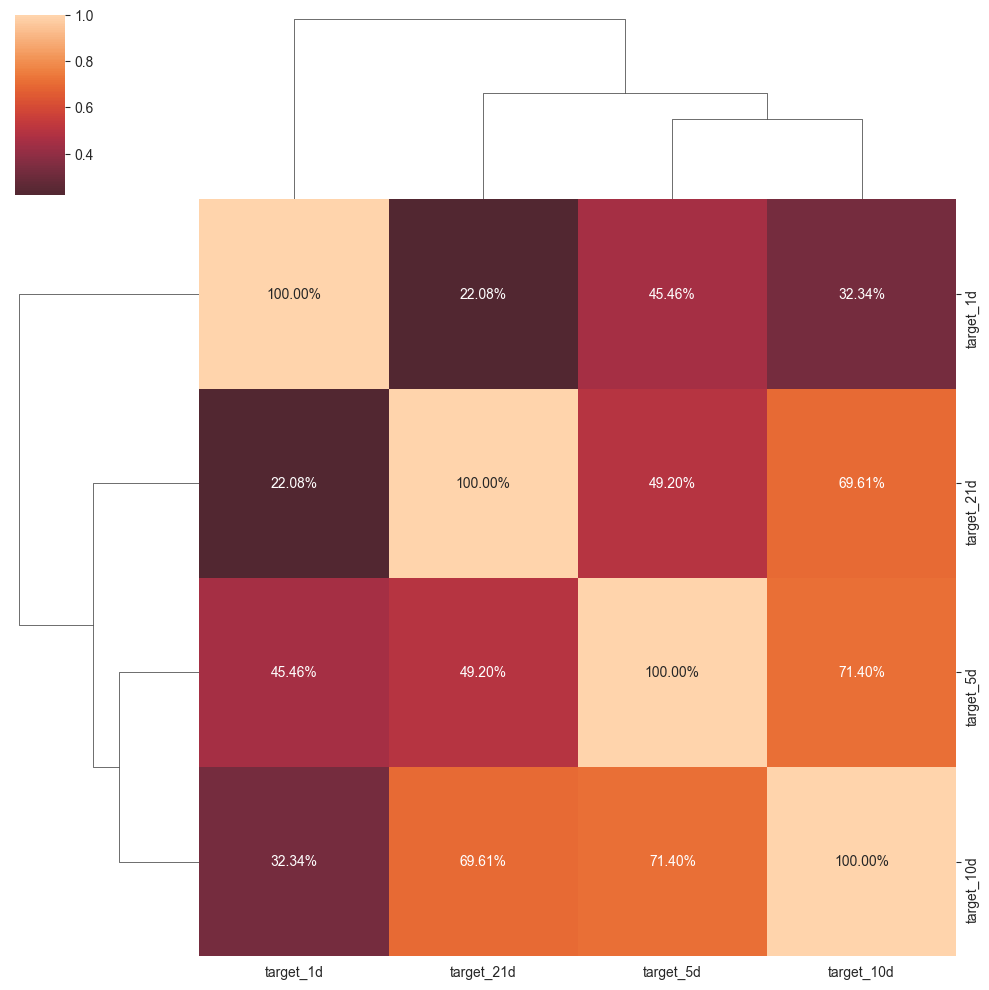

In [48]:
sns.clustermap(y.corr(), center = 0, annot=True, fmt='.2%')

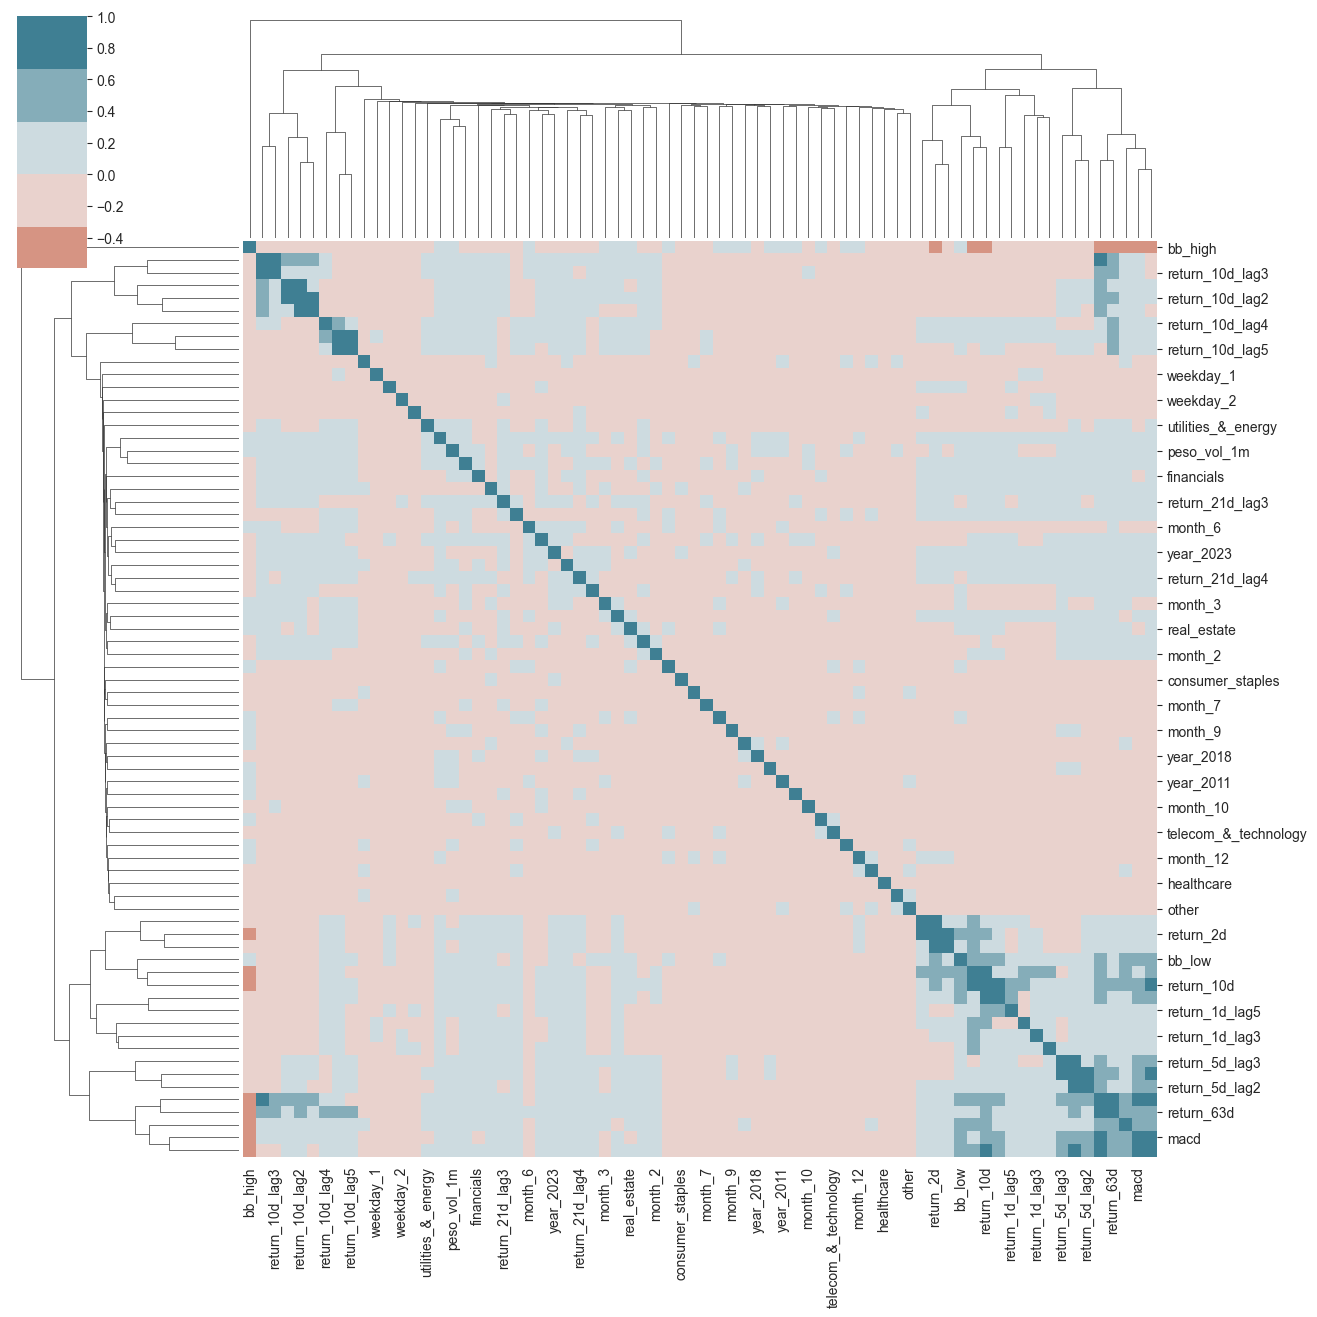

In [49]:
sns.clustermap(X.corr(), cmap=sns.diverging_palette(h_neg=20, h_pos=220), center=0);
plt.gcf().set_size_inches((14, 14))

In [50]:
corr_mat = X.corr().stack().reset_index()
corr_mat.columns = ['var1', 'var2', 'corr']
corr_mat = corr_mat[corr_mat.var1 != corr_mat.var2].sort_values(by='corr', ascending = False)

In [51]:
pd.concat([corr_mat.head(), corr_mat.tail()])

,var1,var2,corr
875,return_63d,return_42d,0.817552
804,return_42d,return_63d,0.817552
370,macd,return_21d,0.758261
725,return_21d,macd,0.758261
797,return_42d,macd,0.742630
154,bb_high,return_21d,-0.523575
578,return_5d,bb_high,-0.528063
152,bb_high,return_5d,-0.528063
153,bb_high,return_10d,-0.594008
650,return_10d,bb_high,-0.594008


<Axes: >

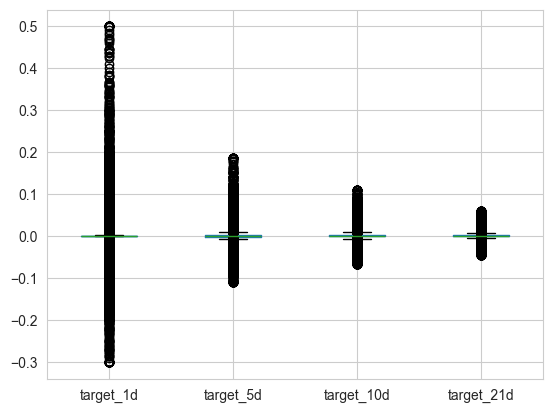

In [52]:
y.boxplot()

# Linear regression for statistical inference : OLS with statsmodels

## Ticker wise standardization

```statsmodels``` warns of high design matrix condition numbers. This can arise when the variables are not standardized and the Eigenvalues differ due to scaling. The following step avoids this warning.

In [63]:
binary = X.iloc[ : , -39 : ]
X = (
    X.drop(binary.columns, axis = 1)
    .groupby(level = 'Ticker')
    .transform(lambda x: (x - x.mean()) / x.std())
    .join(binary)
    .fillna(0)
)

## 1-day returns

In [69]:
target = 'target_1d'
model = OLS(endog= y[target], exog = add_constant(X))
trained_model = model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:              target_1d   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     55.05
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:22:30   Log-Likelihood:             1.0074e+06
No. Observations:              391307   AIC:                        -2.015e+06
Df Residuals:                  391234   BIC:                        -2.014e+06
Df Model:                          72                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0018 

## 5 day returns

In [70]:
target = 'target_5d'
model = OLS(endog = y[target], exog = add_constant(X))
trained_model = model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:              target_5d   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     111.1
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:23:44   Log-Likelihood:             1.3052e+06
No. Observations:              391307   AIC:                        -2.610e+06
Df Residuals:                  391234   BIC:                        -2.609e+06
Df Model:                          72                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0019 

### obtain the residuals

In [71]:
preds = trained_model.predict(add_constant(X))
residuals = y[target] - preds

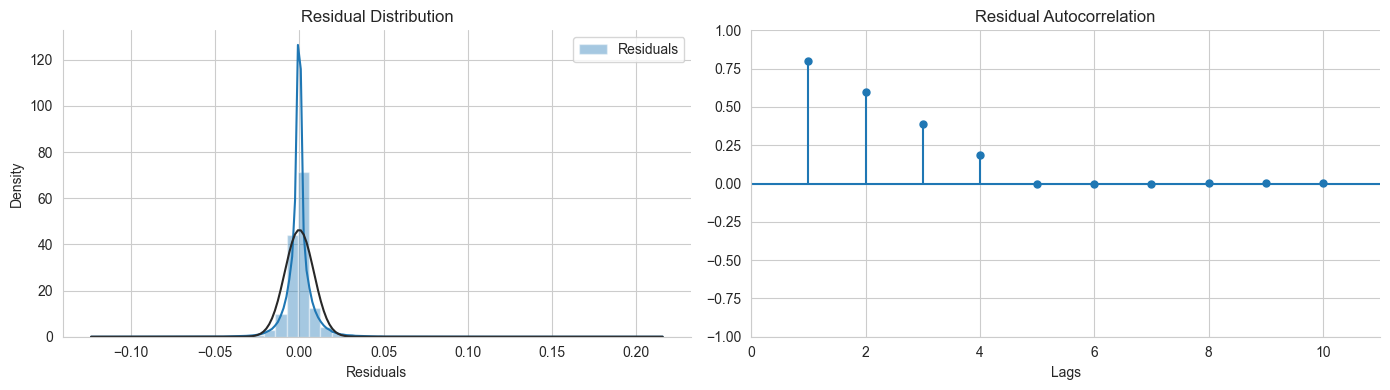

In [72]:
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
sns.distplot(residuals, fit=norm, ax=axes[0], axlabel='Residuals', label='Residuals')
axes[0].set_title('Residual Distribution')
axes[0].legend()
plot_acf(residuals, lags=10, zero=False, ax=axes[1], title='Residual Autocorrelation')
axes[1].set_xlabel('Lags')
sns.despine()
fig.tight_layout();

## 10 day returns

In [73]:
target = 'target_10d'
model = OLS(endog=y[target], exog=add_constant(X))
trained_model = model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:             target_10d   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     175.4
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:27:11   Log-Likelihood:             1.4402e+06
No. Observations:              391307   AIC:                        -2.880e+06
Df Residuals:                  391234   BIC:                        -2.879e+06
Df Model:                          72                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0018 

## Monthly returns

In [74]:
target = 'target_21d'
model = OLS(endog=y[target], exog=add_constant(X))
trained_model = model.fit()
print(trained_model.summary())

                            OLS Regression Results                            
Dep. Variable:             target_21d   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     279.1
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:27:14   Log-Likelihood:             1.5856e+06
No. Observations:              391307   AIC:                        -3.171e+06
Df Residuals:                  391234   BIC:                        -3.170e+06
Df Model:                          72                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0015 